# Deep learning on images

## Load modules from repo

In [1]:
# Le code suivant dans un notebook permet de :
# - autoriser les imports de fichiers python de ce repo
# - spécifier les chemins relativement à la racine du repo plutôt que relativement au notebook

import os

# Ce code cherche le dossier racine en remontant dans l'arborescence
# jusqu'à ce qu'il trouve le dossier 'src'.
# Cela le rend indépendant de l'endroit où vous lancez le notebook.
try:
    # On part du dossier du notebook
    notebook_dir = os.path.dirname(__file__)
except NameError:
    # __file__ n'existe pas en mode interactif, on utilise le répertoire de travail
    notebook_dir = os.getcwd()

# On remonte jusqu'à trouver un dossier contenant 'src'
project_root = notebook_dir
while not os.path.isdir(os.path.join(project_root, 'src')):
    parent_dir = os.path.dirname(project_root)
    if parent_dir == project_root: # On a atteint la racine du système
        raise FileNotFoundError("Impossible de trouver le dossier 'src'. Vérifiez la structure du projet.")
    project_root = parent_dir

os.chdir(project_root)

In [2]:
os.getcwd()

'/home/val/Documents/Dev/DataScientest/Rakuten'

In [3]:
import src
from src.preprocessing.core import load_reproducible_split
from src.preprocessing.pipelines.deep_learning_on_images import preprocess_features
from src.preprocessing.pipelines.deep_learning import load_preprocessors, save_preprocessors
from src.models.on_images.deep_learning import define_model, get_efficientnet_selection
from src.models.on_text_and_images.deep_learning import get_custom_hyperparams, log_experiment, grad_cam, show_grad_cam_cnn

from pathlib import Path
import pandas as pd
# import numpy as np

2025-11-21 12:58:39.284278: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-21 12:58:39.711746: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-21 12:58:40.926853: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1763726322.519572    8241 gpu_device.cc:2020] Created device /job:localhost/rep

In [4]:
import importlib
importlib.reload(src.preprocessing.core)
importlib.reload(src.preprocessing.pipelines.deep_learning_on_images)
importlib.reload(src.models.on_images.deep_learning)
importlib.reload(src.models.on_text_and_images.deep_learning)

<module 'src.models.on_text_and_images.deep_learning' from '/home/val/Documents/Dev/DataScientest/Rakuten/src/models/on_text_and_images/deep_learning.py'>

## Load tensorflow

In [5]:
import tensorflow as tf

In [6]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [7]:
print(f"tensorflow: {tf.__version__}")

tensorflow: 2.20.0


## Load split dataset

In [8]:
X_train, X_test, y_train, y_test = load_reproducible_split(folder = 'Dataset2')
full_y_train=y_train

In [9]:
# Distribution of class proportions
y_train.value_counts(normalize=True).describe()

count    27.000000
mean      0.037037
std       0.024767
min       0.008994
25%       0.018268
50%       0.031458
75%       0.056137
max       0.120223
Name: proportion, dtype: float64

## Configuration 1

In [10]:
modality = 'image'
version=1
artifacts_folder=Path(f'artifacts/on_images/deep_learning/v{version}')

multimodal_artifacts_folder = Path(f'artifacts/on_text_and_images/deep_learning/v1')
log_file_path = multimodal_artifacts_folder / 'experiments.parquet'
preprocessors_folder = multimodal_artifacts_folder
tensor_board_folder = multimodal_artifacts_folder / "tensorboard_logs"

# fit_preprocessors=True
fit_preprocessors=False

small_train_sample = False  # TODO: set to False for real training or fitting preprocessors
frac=0.1

rebalance_with_weights = True  # True is useful if some classes are ignored by the model. In that case, small_train_sample should be False.

# augment=True  # Augment data for training
augment=False

BATCH_SIZE = 32

RANDOM_SEED = 42

load_model=True
# load_model=False

# index_of_last_experiment=-1  # default (last experiment)
index_of_last_experiment=10  # (best image model so far)

## Preprocessing

In [11]:
if fit_preprocessors and small_train_sample:
    raise ValueError("When fit_preprocessors=True, small_train_sample should be False so that encoders are fitted on the full training dataset.")

In [12]:
if small_train_sample:
    print(f"{small_train_sample=}")
    X_train=X_train.sample(frac=frac, random_state=RANDOM_SEED)
    y_train=y_train.loc[X_train.index]

In [13]:
y_train.value_counts(normalize=True).describe()

count    27.000000
mean      0.037037
std       0.024767
min       0.008994
25%       0.018268
50%       0.031458
75%       0.056137
max       0.120223
Name: proportion, dtype: float64

In [14]:
y_train.value_counts().describe()

count      27.000000
mean     2516.000000
std      1682.489662
min       611.000000
25%      1241.000000
50%      2137.000000
75%      3813.500000
max      8167.000000
Name: count, dtype: float64

In [15]:
print(X_train.shape)

(67932, 31)


In [16]:
if fit_preprocessors:
    preprocessors = {}
    print('will fit')
else: # load preprocessors
    print('loading')
    preprocessors = load_preprocessors(names=['target','tabular','hash'],artifacts_folder=preprocessors_folder)

loading
artifacts/on_text_and_images/deep_learning/v1/preprocessors/target.joblib
artifacts/on_text_and_images/deep_learning/v1/preprocessors/tabular.joblib
artifacts/on_text_and_images/deep_learning/v1/preprocessors/hash.joblib


In [17]:
train_ds, new_preprocessors, class_weights, train_inputs_dict, y_train_ohe = preprocess_features(X_train, y_train, preprocessors, full_y_train=full_y_train, shuffle=True, BATCH_SIZE = BATCH_SIZE, rebalance_with_weights=rebalance_with_weights, augment=augment)
preprocessors |= new_preprocessors
n_cols_tabular = train_inputs_dict['tabular_input'].shape[1]
n_cols_tabular

24

In [18]:
new_preprocessors

{}

In [19]:
# Save on disk
if fit_preprocessors:
    print('Saving.')
    save_preprocessors(new_preprocessors,artifacts_folder)

In [20]:
test_ds, new_preprocessors, class_weights_test, test_inputs_dict, y_test_ohe = preprocess_features(X_test, y_test, preprocessors, shuffle=False, BATCH_SIZE = BATCH_SIZE, rebalance_with_weights=False, augment=False)

## Model

In [21]:
from tensorflow import keras

### Load or create model

In [22]:
import pandas as pd

try:
    # Load tracker
    tracking_df = pd.read_parquet(log_file_path)
    if tracking_df.empty:
        last_experiment = {}
    else:
        last_experiment = tracking_df.iloc[index_of_last_experiment].to_dict()
except FileNotFoundError:
    last_experiment = {}

champion_path=None
if load_model:
    # Récupérer le total d'epochs déjà entraînées
    total_epochs_trained = last_experiment.get('total_epochs', 0)

    arch_version = last_experiment.get('arch_version', 1)

    # Charger le meilleur modèle connu jusqu'à présent (le "champion")
    champion_path = last_experiment.get('best_model_path', None)
    if champion_path and Path(champion_path).exists():
        print(f"Reprise depuis le meilleur modèle de l'expérience : {champion_path}")
        model = keras.models.load_model(champion_path)
        _, base_model = define_model(pHash_vocab_size=len(preprocessors['hash'].categories_[0]), md5_vocab_size=len(preprocessors['hash'].categories_[1]), n_cols_tabular=n_cols_tabular, num_classes=27)
    else:
        raise FileNotFoundError("Consider setting load_model=False.")
else:
    arch_version = last_experiment.get('arch_version', 0)
    total_epochs_trained = 0
    last_experiment = {}
    print("Création d'un nouveau modèle.")
    model, base_model = define_model(pHash_vocab_size=len(preprocessors['hash'].categories_[0]), md5_vocab_size=len(preprocessors['hash'].categories_[1]), n_cols_tabular=n_cols_tabular, num_classes=27)


Reprise depuis le meilleur modèle de l'expérience : artifacts/on_images/deep_learning/v1/best_model_sv-9_epoch_index-01_val_accuracy-0.6365_f1-0.6253.keras


In [23]:
if not load_model:
    arch_version = int(input(f"arch_version ? (last: {arch_version})"))

In [24]:
arch_version

9

### Summary

In [25]:
# model.summary()

## Callbacks

### ModelCheckpoint

In [26]:
# # Pick an available filename to save a model.
# arch_version=1
# while True:
#     new_location_for_saving_model = Path(artifacts_folder / f'best_model-{arch_version}.keras')
#     if not new_location_for_saving_model.exists():
#         break
#     arch_version+=1
# # new_location_for_saving_model_weights = Path(artifacts_folder / f'best_model-{arch_version}.h5')
# new_location_for_saving_model


In [27]:
new_location_for_saving_model = artifacts_folder / "candidate_best_model.keras"

In [28]:
# Callback pour sauvegarder le meilleur modèle au fur et à mesure
save = keras.callbacks.ModelCheckpoint(
    new_location_for_saving_model,
    save_best_only=True,
    monitor='val_accuracy',
    mode='max'
)

In [29]:
# # ou sauvegarder l'intégralité du modèle après l'entraînement, c'est-à-dire son architecture et ses poids :
# model.save(new_location_for_saving_model)

### EarlyStopping

In [30]:
from tensorflow.keras.callbacks import EarlyStopping

# Ce callback arrêtera l'entraînement si la métrique ne s'améliore pas
# pendant n epochs consécutives. Il restaurera aussi les poids du meilleur epoch.
early_stopping = EarlyStopping(
    monitor='val_accuracy', # La métrique à surveiller
    patience=5,             # Nombre d'epochs à attendre sans amélioration
    mode='max',             # Choisir le mode selon la métrique à surveiller
    restore_best_weights=True # À la fin, le modèle aura les poids de son meilleur score
)

### ReduceLROnPlateau

In [31]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(
    monitor='val_accuracy', # On surveille la perte sur la validation
    factor=0.2,         # On réduit le LR
    patience=2,         # Si métrique stagne pendant n epochs
    min_lr=1e-6,        # On ne descend pas en dessous de cette valeur
    verbose=1           # Affiche un message quand le LR est réduit
)

### TerminateOnNaN

In [32]:
import tensorflow.keras.callbacks as callbacks
terminate_on_nan = callbacks.TerminateOnNaN()

### TensorBoard

In [33]:
import datetime
timestamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensor_board = callbacks.TensorBoard(
    log_dir = tensor_board_folder / f"{timestamp}-{modality}",
    histogram_freq=1  # Demande à Keras de logger les distributions des poids et biais à chaque epoch
)

## Configuration 2

### max_epochs

In [34]:
import math
# typical_minutes_per_epoch=2.058333 * X_train.shape[0] / 6793
typical_minutes_per_epoch=8.6 * X_train.shape[0] / 67932

In [35]:
max_epochs=10

# Calculate expected duration
available_minutes=math.ceil(max_epochs * typical_minutes_per_epoch)
available_minutes

86

In [36]:
# # Pick max_epochs based on your available time
# available_minutes=60

# max_epochs=math.floor(available_minutes/typical_minutes_per_epoch)
# max_epochs

### compilation and callbacks

In [37]:
learning_rate=0.001

In [38]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [39]:
callbacks = [save, early_stopping, reduce_lr, terminate_on_nan, tensor_board]

## Training

In [40]:
raise Exception(f"Are you sure you want to launch training with {available_minutes=}, {max_epochs=}, {champion_path=} ?")

Exception: Are you sure you want to launch training with available_minutes=86, max_epochs=10, champion_path='artifacts/on_images/deep_learning/v1/best_model_sv-9_epoch_index-01_val_accuracy-0.6365_f1-0.6253.keras' ?

In [ ]:
import time
start = time.time()
model_history = model.fit(train_ds, validation_data=test_ds, epochs=total_epochs_trained + max_epochs, initial_epoch=total_epochs_trained, callbacks=callbacks)
end = time.time()
total_minutes = (end - start)/60
f"{total_minutes=}"

## Epoch curves

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.subplot(121)
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title('Model loss by epoch')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='right')

plt.subplot(122)
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('Model accuracy by epoch')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='right');

## Grad-CAM

In [ ]:
raise Exception("This section takes a while to run.")

In [41]:
from tensorflow.keras import layers

conv_layers = [layer.name for layer in model.layers if isinstance(layer, layers.Conv2D)]
print(len(conv_layers))

75


In [42]:
conv_layers

['stem_conv',
 'block1a_project_conv',
 'block2a_expand_conv',
 'block2a_project_conv',
 'block2b_expand_conv',
 'block2b_project_conv',
 'block3a_expand_conv',
 'block3a_project_conv',
 'block3b_expand_conv',
 'block3b_project_conv',
 'block4a_expand_conv',
 'block4a_se_reduce',
 'block4a_se_expand',
 'block4a_project_conv',
 'block4b_expand_conv',
 'block4b_se_reduce',
 'block4b_se_expand',
 'block4b_project_conv',
 'block4c_expand_conv',
 'block4c_se_reduce',
 'block4c_se_expand',
 'block4c_project_conv',
 'block5a_expand_conv',
 'block5a_se_reduce',
 'block5a_se_expand',
 'block5a_project_conv',
 'block5b_expand_conv',
 'block5b_se_reduce',
 'block5b_se_expand',
 'block5b_project_conv',
 'block5c_expand_conv',
 'block5c_se_reduce',
 'block5c_se_expand',
 'block5c_project_conv',
 'block5d_expand_conv',
 'block5d_se_reduce',
 'block5d_se_expand',
 'block5d_project_conv',
 'block5e_expand_conv',
 'block5e_se_reduce',
 'block5e_se_expand',
 'block5e_project_conv',
 'block6a_expand_conv

In [43]:
# # 1. Define your step for the middle section (e.g., every 10th layer)
# n = 10

# # 2. Slice the list
# start_layers = conv_layers[:5]
# end_layers = conv_layers[-5:]
# middle_layers = conv_layers[5:-5:n]

# # 3. Combine and remove duplicates (using dict.fromkeys preserves order)
# selected_layers = list(dict.fromkeys(start_layers + middle_layers + end_layers))

# print(f"Selected {len(selected_layers)} layers out of {len(conv_layers)}")
# print(selected_layers)

In [44]:
# selected_layers = get_efficientnet_selection(conv_layers)
selected_layers=['block3b_project_conv', 'block5e_project_conv', 'top_conv']

print(f"Selected {len(selected_layers)} layers:")
print(selected_layers)

Selected 3 layers:
['block3b_project_conv', 'block5e_project_conv', 'top_conv']


In [55]:
# Load some random images from the first 300 images of the test dataset
number_of_images = 4

# 1. unbatch(): breaks the (16, 500, 500, 3) batches into individual (500, 500, 3) items
# 2. shuffle(buffer_size): loads 'buffer_size' items into memory and picks randomly from them.
#    Note: Set buffer_size >= number_of_images (ideally larger, e.g., 100 or 1000 for better randomness).
#          (But buffer_size=2000 takes about 6 seconds. And too big would take too much RAM.)
# 3. batch(number_of_images): groups them back into a batch of 4
# 4. take(1): takes that single batch of 4
random_batch = test_ds.unbatch().shuffle(buffer_size=1200).batch(number_of_images).take(1)

for inputs_dict, labels_batch in random_batch:
    labels = labels_batch.numpy().argmax(axis=1)
    break

print(inputs_dict.keys(), labels.shape)

dict_keys(['tabular_input', 'pHash_input', 'md5_input', 'image_input']) (4,)


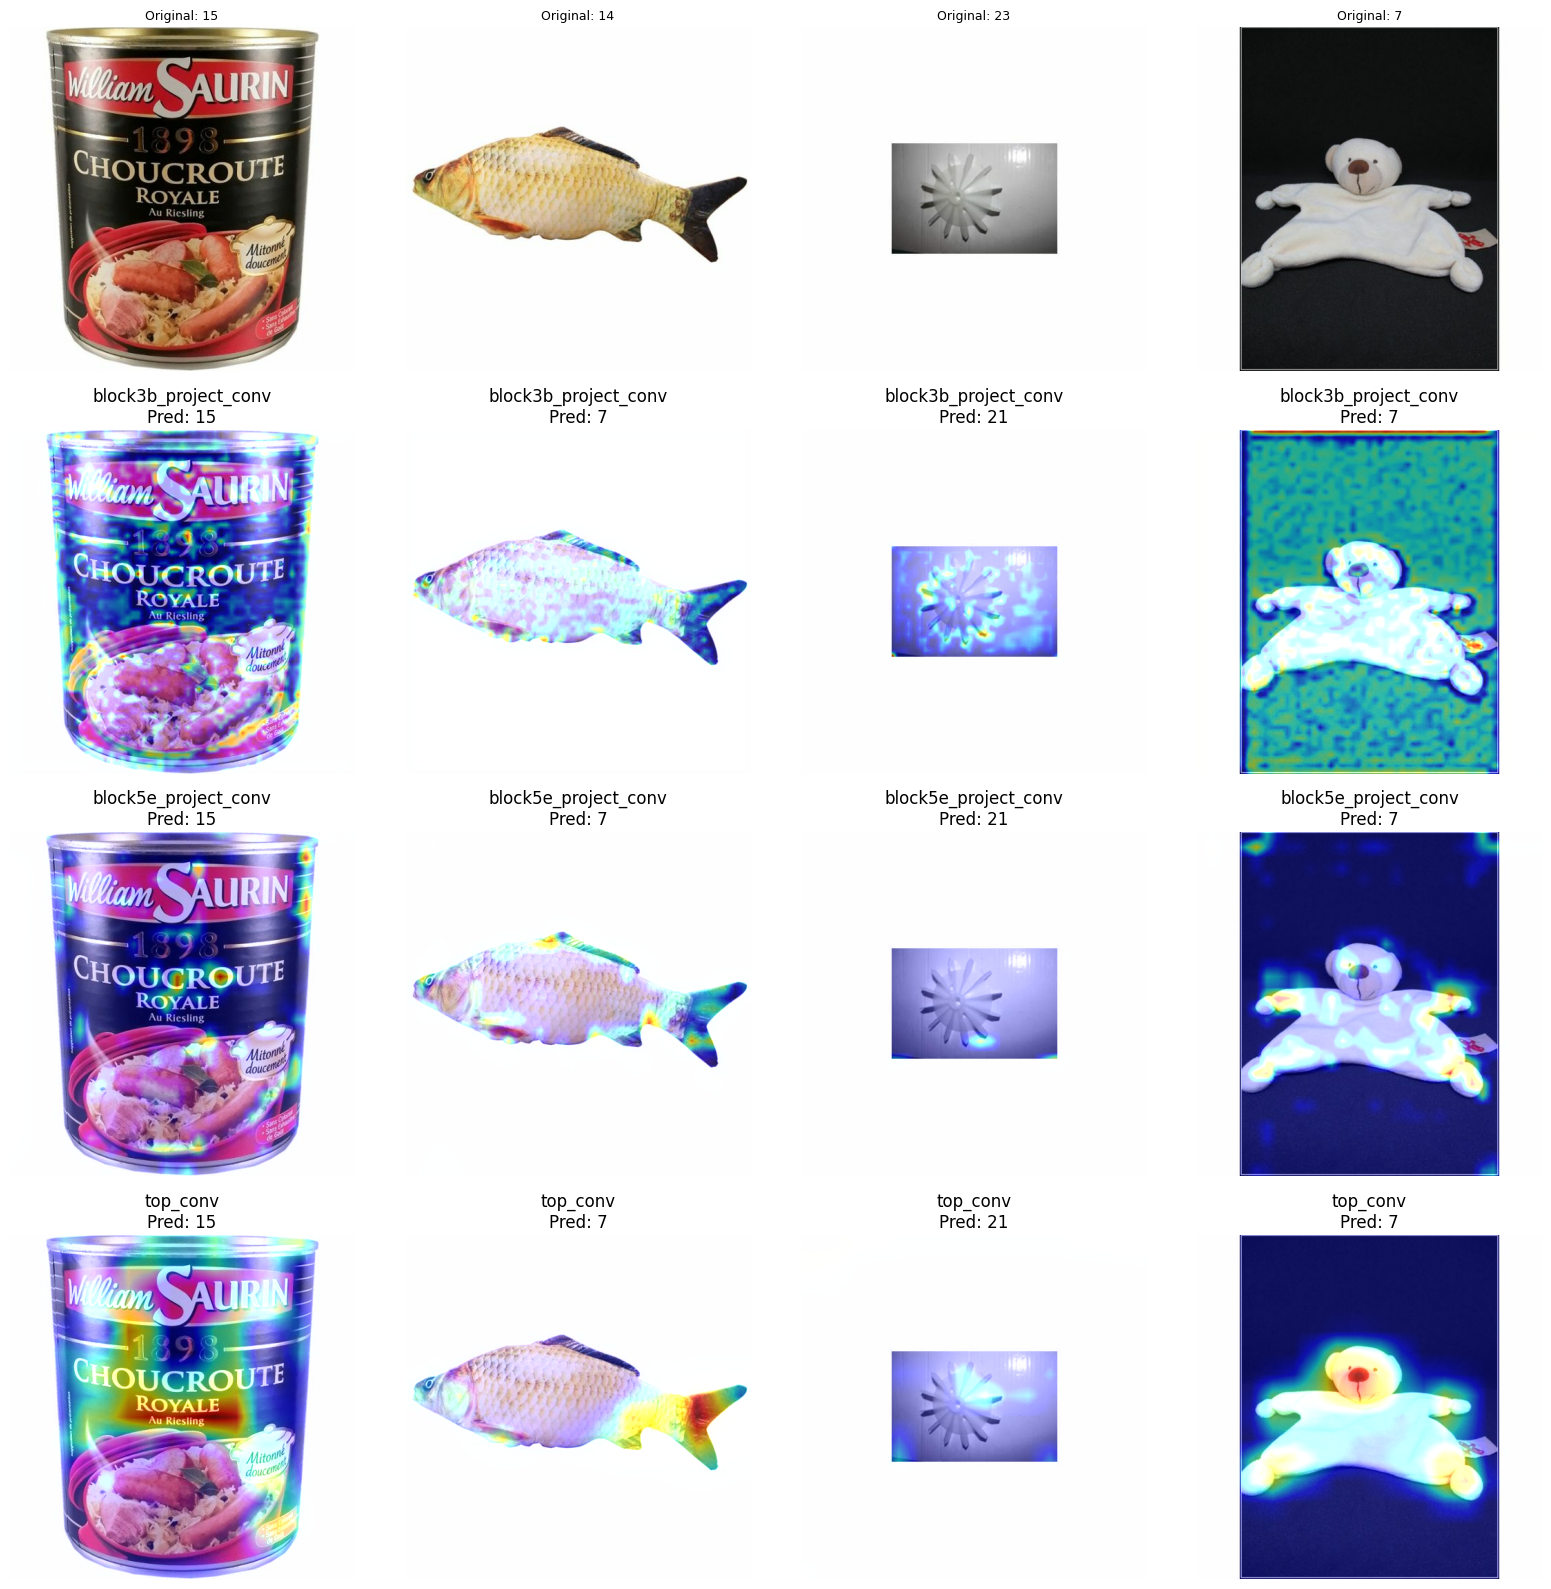

In [56]:
# Takes 10s for 3 layers.
save_plot=True
# save_plot=False
hashes=show_grad_cam_cnn(inputs_dict, model, selected_layers, labels, preprocessors["hash"], save_plot)

In [ ]:
for (k,hash) in enumerate(hashes):
    print(k,end=': ')
    if hash is None:
        print("hash unknown.")
    else:
        display(X_test[X_test['image_hash_md5']==hash])

0: hash unknown.
1: hash unknown.
2: hash unknown.
3: hash unknown.


## Evaluation

In [ ]:
print(f"source venv/bin/activate\ntensorboard --logdir '{tensor_board_folder.resolve()}'")
# To use tensorboard:
# open a terminal and run the two commands below.

In [ ]:
tracker = {}
tracker['X_train.shape[0]']=X_train.shape[0]
tracker['actual_epochs']=model_history.epoch[-1] + 1
tracker['minutes_per_epoch'] = total_minutes / tracker['actual_epochs']
tracker

In [ ]:
tracker['minutes_per_epoch']=max(tracker['minutes_per_epoch'], last_experiment.get('minutes_per_epoch',0))

In [ ]:
#Takes 1m40
y_pred = model.predict(test_ds)

In [ ]:
from sklearn import metrics

In [ ]:
y_test_class = preprocessors['target'].inverse_transform(y_test_ohe.argmax(axis=1))
y_pred_class = preprocessors['target'].inverse_transform(y_pred.argmax(axis=1))

In [ ]:
pd.set_option('display.max_columns',None)
pd.crosstab(y_test_class, y_pred_class, rownames=['True'], colnames=['Predicted'])

In [ ]:
candidate_f1_score=metrics.f1_score(y_test_class, y_pred_class, average='weighted')
champion_f1_score = last_experiment.get('weighted_avg_f1_score', 0.0)
candidate_f1_score, champion_f1_score

In [ ]:
tracker['weighted_avg_f1_score'] = candidate_f1_score

In [ ]:
import pandas as pd
report=metrics.classification_report(y_test_class, y_pred_class, output_dict=True)
report=pd.DataFrame(report).transpose()
report

In [ ]:
# Summary over classes
report.iloc[:-3].describe()

In [ ]:
# positive correlation between support and another measure can suggest class imbalance hurts performance
report.corr()

In [ ]:
tracker['weighted_avg_f1_score']=metrics.f1_score(y_test_class, y_pred_class, average='weighted')
tracker['weighted_avg_f1_score']

In [ ]:
tracker['min_f1_score']=report['f1-score'].iloc[:-3].describe()['min']
tracker['std_f1_score']=report['f1-score'].iloc[:-3].describe()['std']
tracker

## Update tracker

In [ ]:
tracker['comment']="Set augment=False. The train curve is lower, suggesting data augmentation increases overfitting! Validation results are also much better."
tracker['comment']

In [ ]:
import numpy as np
if candidate_f1_score > champion_f1_score:
    print("Sauvegarde du modèle.")
    keep_candidate=True

    best_epoch_in_session_idx = np.argmax(model_history.history['val_accuracy'])
    best_epoch_global = total_epochs_trained + best_epoch_in_session_idx
    best_val_accuracy = model_history.history['val_accuracy'][best_epoch_in_session_idx]
    tracker['val_accuracy'] = best_val_accuracy

    # Construire le nouveau nom de fichier informatif
    new_champion_filename = f"best_model_arch-{arch_version}_epoch_index-{best_epoch_global:02d}_val_accuracy-{best_val_accuracy:.4f}_f1-{candidate_f1_score:.4f}.keras"
    new_champion_path = artifacts_folder / new_champion_filename

    # Renommer le fichier candidat pour en faire le nouveau champion
    os.rename(new_location_for_saving_model, new_champion_path)

    tracker['best_model_path'] = str(new_champion_path)
    print(new_champion_path)

    # Supprimer l'ancien champion pour garder le dossier propre
    if champion_path and Path(champion_path).exists():
        print(f"Effacement de l'ancien modèle chargé {champion_path=} .")
        os.remove(champion_path)
else:
    raise Exception("Le candidat n'a pas battu le modèle chargé.")
    keep_candidate=False


In [ ]:
tracker['epoch_index'] = best_epoch_global
tracker['total_epochs'] = best_epoch_global + 1

In [ ]:
to_track=['version','arch_version','max_epochs','rebalance_with_weights','BATCH_SIZE','learning_rate','timestamp','modality']
tracker |= {k: globals()[k] for k in to_track}
tracker |= get_custom_hyperparams(model, base_model)

In [ ]:
tracker

In [ ]:
if not keep_candidate:
    raise Exception("Sure you want to delete current candidate model?")

In [ ]:
if not keep_candidate:
    os.remove(new_location_for_saving_model)

In [ ]:
raise Exception("Sure you want to save the current values of `tracker`? Consider editing the comment.")

In [ ]:
# Saves tracker as a new row of parquet file (creates the parquet file if necessary)
log_experiment(tracker, loaded_model=load_model, log_file_path=log_file_path)

## Show tracking logs

In [ ]:
pd.set_option('max_colwidth', None)

In [ ]:
tracking_df = pd.read_parquet(log_file_path)
tracking_df

In [ ]:
old_log_file_path='artifacts/on_images/deep_learning/v1/2025-10-02 experiments-v1.parquet'

In [ ]:
tracking_df0 = pd.read_parquet(old_log_file_path)
tracking_df0